In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/katehighnam/beth-dataset/labelled_training_data.csv
/kaggle/input/datasets/katehighnam/beth-dataset/labelled_2021may-ip-10-100-1-4-dns.csv
/kaggle/input/datasets/katehighnam/beth-dataset/labelled_2021may-ip-10-100-1-186-dns.csv
/kaggle/input/datasets/katehighnam/beth-dataset/labelled_validation_data.csv
/kaggle/input/datasets/katehighnam/beth-dataset/labelled_2021may-ip-10-100-1-26-dns.csv
/kaggle/input/datasets/katehighnam/beth-dataset/labelled_2021may-ip-10-100-1-186.csv
/kaggle/input/datasets/katehighnam/beth-dataset/labelled_2021may-ip-10-100-1-4.csv
/kaggle/input/datasets/katehighnam/beth-dataset/labelled_2021may-ip-10-100-1-26.csv
/kaggle/input/datasets/katehighnam/beth-dataset/labelled_2021may-ip-10-100-1-105-dns.csv
/kaggle/input/datasets/katehighnam/beth-dataset/labelled_2021may-ip-10-100-1-95-dns.csv
/kaggle/input/datasets/katehighnam/beth-dataset/labelled_testing_data.csv
/kaggle/input/datasets/katehighnam/beth-dataset/labelled_2021may-ip-10-100-1-105.

In [2]:
!pip install hmmlearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json, joblib
warnings.filterwarnings('ignore')

from hmmlearn import hmm
import hdbscan
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.impute import SimpleImputer
from gensim.models import Word2Vec
from collections import defaultdict

try:
    import umap
    HAS_UMAP = True
    print('UMAP available')
except ImportError:
    HAS_UMAP = False
    print('UMAP not found — using PCA for 2D projection')

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, Model
    HAS_TF = True
    print(f'TF {tf.__version__} ready')
except ImportError:
    HAS_TF = False
    print('TensorFlow not available — Transfer Learning skipped')

PAL = ['#4f7cff','#22c55e','#f59e0b','#ef4444','#8b5cf6','#06b6d4','#ec4899','#14b8a6']
RANDOM = 42
np.random.seed(RANDOM)
os.makedirs('models', exist_ok=True)
print('NB3 imports ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.3 MB/s eta 0:00:00


2026-05-02 11:04:21.898189: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777719862.188141      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777719862.270225      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777719862.963354      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777719862.963419      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777719862.963423      16 computation_placer.cc:177] computation placer alr

UMAP available
TF 2.19.0 ready
NB3 imports ready.


In [3]:
# ── BETH has two file types:
#    1. DNS logs  : labelled_2021may-ip-*-dns.csv  (network layer)
#    2. Host logs : labelled_testing/training/validation_data.csv (process layer)
# Adjust paths to your Kaggle dataset slug

import glob

# ── DNS log files
DNS_PATTERN = '/kaggle/input/datasets/katehighnam/beth-dataset/labelled_2021may*-dns.csv'
dns_files   = sorted(glob.glob(DNS_PATTERN))
print(f'DNS files found: {len(dns_files)}')

# Host log files
TRAIN_HOST = '/kaggle/input/datasets/katehighnam/beth-dataset/labelled_training_data.csv'
TEST_HOST  = '/kaggle/input/datasets/katehighnam/beth-dataset/labelled_training_data.csv'
VAL_HOST   = '/kaggle/input/datasets/katehighnam/beth-dataset/labelled_validation_data.csv'

# Load DNS logs (combine all)
dns_dfs = []
for f in dns_files:
    try:
        tmp = pd.read_csv(f, low_memory=False)
        tmp['source_file'] = os.path.basename(f)
        dns_dfs.append(tmp)
    except Exception as e:
        print(f'  skip {f}: {e}')

df_dns = pd.concat(dns_dfs, ignore_index=True) if dns_dfs else pd.DataFrame()
print(f'DNS logs combined: {df_dns.shape}')
if not df_dns.empty:
    print(f'DNS columns: {list(df_dns.columns)}')
    print(f'DNS sus/evil:\n{df_dns[["sus","evil"]].value_counts()}')

# Load host logs
df_train_h = pd.read_csv(TRAIN_HOST, low_memory=False)
df_test_h  = pd.read_csv(TEST_HOST,  low_memory=False)
df_val_h   = pd.read_csv(VAL_HOST,   low_memory=False)
df_host    = pd.concat([df_train_h, df_val_h], ignore_index=True)

print(f'\nHost log columns: {list(df_train_h.columns)}')
print(f'Host train shape : {df_train_h.shape}')
print(f'Host test  shape : {df_test_h.shape}')
print(f'\nHost sus/evil distribution (train):')
print(df_train_h[['sus','evil']].value_counts())

DNS files found: 6
DNS logs combined: (1614, 16)
DNS columns: ['Timestamp', 'SourceIP', 'DestinationIP', 'DnsQuery', 'DnsAnswer', 'DnsAnswerTTL', 'DnsQueryNames', 'DnsQueryClass', 'DnsQueryType', 'NumberOfAnswers', 'DnsResponseCode', 'DnsOpCode', 'SensorId', 'sus', 'evil', 'source_file']
DNS sus/evil:
sus  evil
0    0       1488
1    0        102
     1         24
Name: count, dtype: int64

Host log columns: ['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId', 'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName', 'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil']
Host train shape : (763144, 16)
Host test  shape : (763144, 16)

Host sus/evil distribution (train):
sus  evil
0    0       761875
1    0         1269
Name: count, dtype: int64


In [4]:
# ════════════════════════════════════════════════════════
# DNS FEATURES
# ════════════════════════════════════════════════════════
DNS_FEAT_COLS = [
    'NumberOfAnswers','DnsAnswerTTL','DnsQueryClass','DnsQueryType',
    'DnsResponseCode','DnsOpCode',
]

def engineer_dns_features(df):
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Encode categoricals
    for col in ['DnsQueryNames','DnsQueryClass','DnsQueryType','DnsResponseCode','DnsOpCode']:
        if col in df.columns:
            df[col] = LabelEncoder().fit_transform(df[col].astype(str).fillna('unknown'))

    # Query name entropy (suspicious domains tend to have high entropy)
    if 'DnsQuery' in df.columns:
        def domain_entropy(d):
            d = str(d).lower()
            if not d: return 0.0
            from collections import Counter
            counts = Counter(d)
            total  = len(d)
            return -sum((v/total)*np.log2(v/total) for v in counts.values())
        df['dns_query_entropy'] = df['DnsQuery'].apply(domain_entropy)
        df['dns_query_len']     = df['DnsQuery'].apply(lambda x: len(str(x)))
        df['dns_has_digits']    = df['DnsQuery'].apply(
            lambda x: sum(c.isdigit() for c in str(x)) / max(len(str(x)),1))
        DNS_FEAT_COLS.extend(['dns_query_entropy','dns_query_len','dns_has_digits'])

    # TTL features
    if 'DnsAnswerTTL' in df.columns:
        df['DnsAnswerTTL'] = pd.to_numeric(df['DnsAnswerTTL'], errors='coerce').fillna(0)
        df['dns_ttl_low']  = (df['DnsAnswerTTL'] < 300).astype(int)

    avail = [c for c in list(dict.fromkeys(DNS_FEAT_COLS)) if c in df.columns]
    df[avail] = SimpleImputer(strategy='median').fit_transform(df[avail])
    return df, avail

if not df_dns.empty:
    df_dns, DNS_FEATS = engineer_dns_features(df_dns)
    print(f'DNS features: {len(DNS_FEATS)} -> {DNS_FEATS}')
    print(f'DNS label distribution: sus={df_dns["sus"].sum()} evil={df_dns["evil"].sum()}')

# ════════════════════════════════════════════════════════
# HOST FEATURES
# ════════════════════════════════════════════════════════
HOST_FEAT_COLS = ['processId','threadId','parentProcessId','userId',
                  'mountNamespace','eventId','argsNum','returnValue']

def engineer_host_features(df):
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Encode processName and hostName
    for col in ['processName','hostName','eventName']:
        if col in df.columns:
            df[col+'_enc'] = LabelEncoder().fit_transform(
                df[col].astype(str).fillna('unknown'))
            HOST_FEAT_COLS.append(col+'_enc')

    # Args length as feature (longer args = more suspicious)
    if 'args' in df.columns:
        df['args_len']       = df['args'].apply(lambda x: len(str(x)))
        df['args_has_slash'] = df['args'].apply(
            lambda x: int('/' in str(x) or '\\' in str(x)))
        df['args_has_exec']  = df['args'].apply(
            lambda x: int(any(k in str(x).lower()
                              for k in ['exec','chmod','curl','wget','python','bash','sh'])))
        HOST_FEAT_COLS.extend(['args_len','args_has_slash','args_has_exec'])

    # stackAddresses depth
    if 'stackAddresses' in df.columns:
        df['stack_depth'] = df['stackAddresses'].apply(
            lambda x: len(str(x).split(',')) if pd.notna(x) else 0)
        HOST_FEAT_COLS.append('stack_depth')

    avail = [c for c in list(dict.fromkeys(HOST_FEAT_COLS)) if c in df.columns]
    imp   = SimpleImputer(strategy='median')
    df[avail] = imp.fit_transform(df[avail])
    return df, avail, imp

df_host, HOST_FEATS, host_imputer = engineer_host_features(df_host)
df_test_h, _, _                   = engineer_host_features(df_test_h)

# Align test columns
for c in HOST_FEATS:
    if c not in df_test_h.columns:
        df_test_h[c] = 0

print(f'\nHost features: {len(HOST_FEATS)} -> {HOST_FEATS}')
print(f'Host label sus : {df_host["sus"].sum():,}')
print(f'Host label evil: {df_host["evil"].sum():,}')

# Save
joblib.dump(host_imputer, 'models/v2_host_imputer.pkl')
with open('models/v2_host_features.json','w') as f: json.dump(HOST_FEATS, f)
with open('models/v2_dns_features.json','w') as f:
    json.dump(DNS_FEATS if not df_dns.empty else [], f)
print('Feature metadata saved.')

DNS features: 9 -> ['NumberOfAnswers', 'DnsAnswerTTL', 'DnsQueryClass', 'DnsQueryType', 'DnsResponseCode', 'DnsOpCode', 'dns_query_entropy', 'dns_query_len', 'dns_has_digits']
DNS label distribution: sus=126 evil=24

Host features: 15 -> ['processId', 'threadId', 'parentProcessId', 'userId', 'mountNamespace', 'eventId', 'argsNum', 'returnValue', 'processName_enc', 'hostName_enc', 'eventName_enc', 'args_len', 'args_has_slash', 'args_has_exec', 'stack_depth']
Host label sus : 2,055
Host label evil: 0
Feature metadata saved.


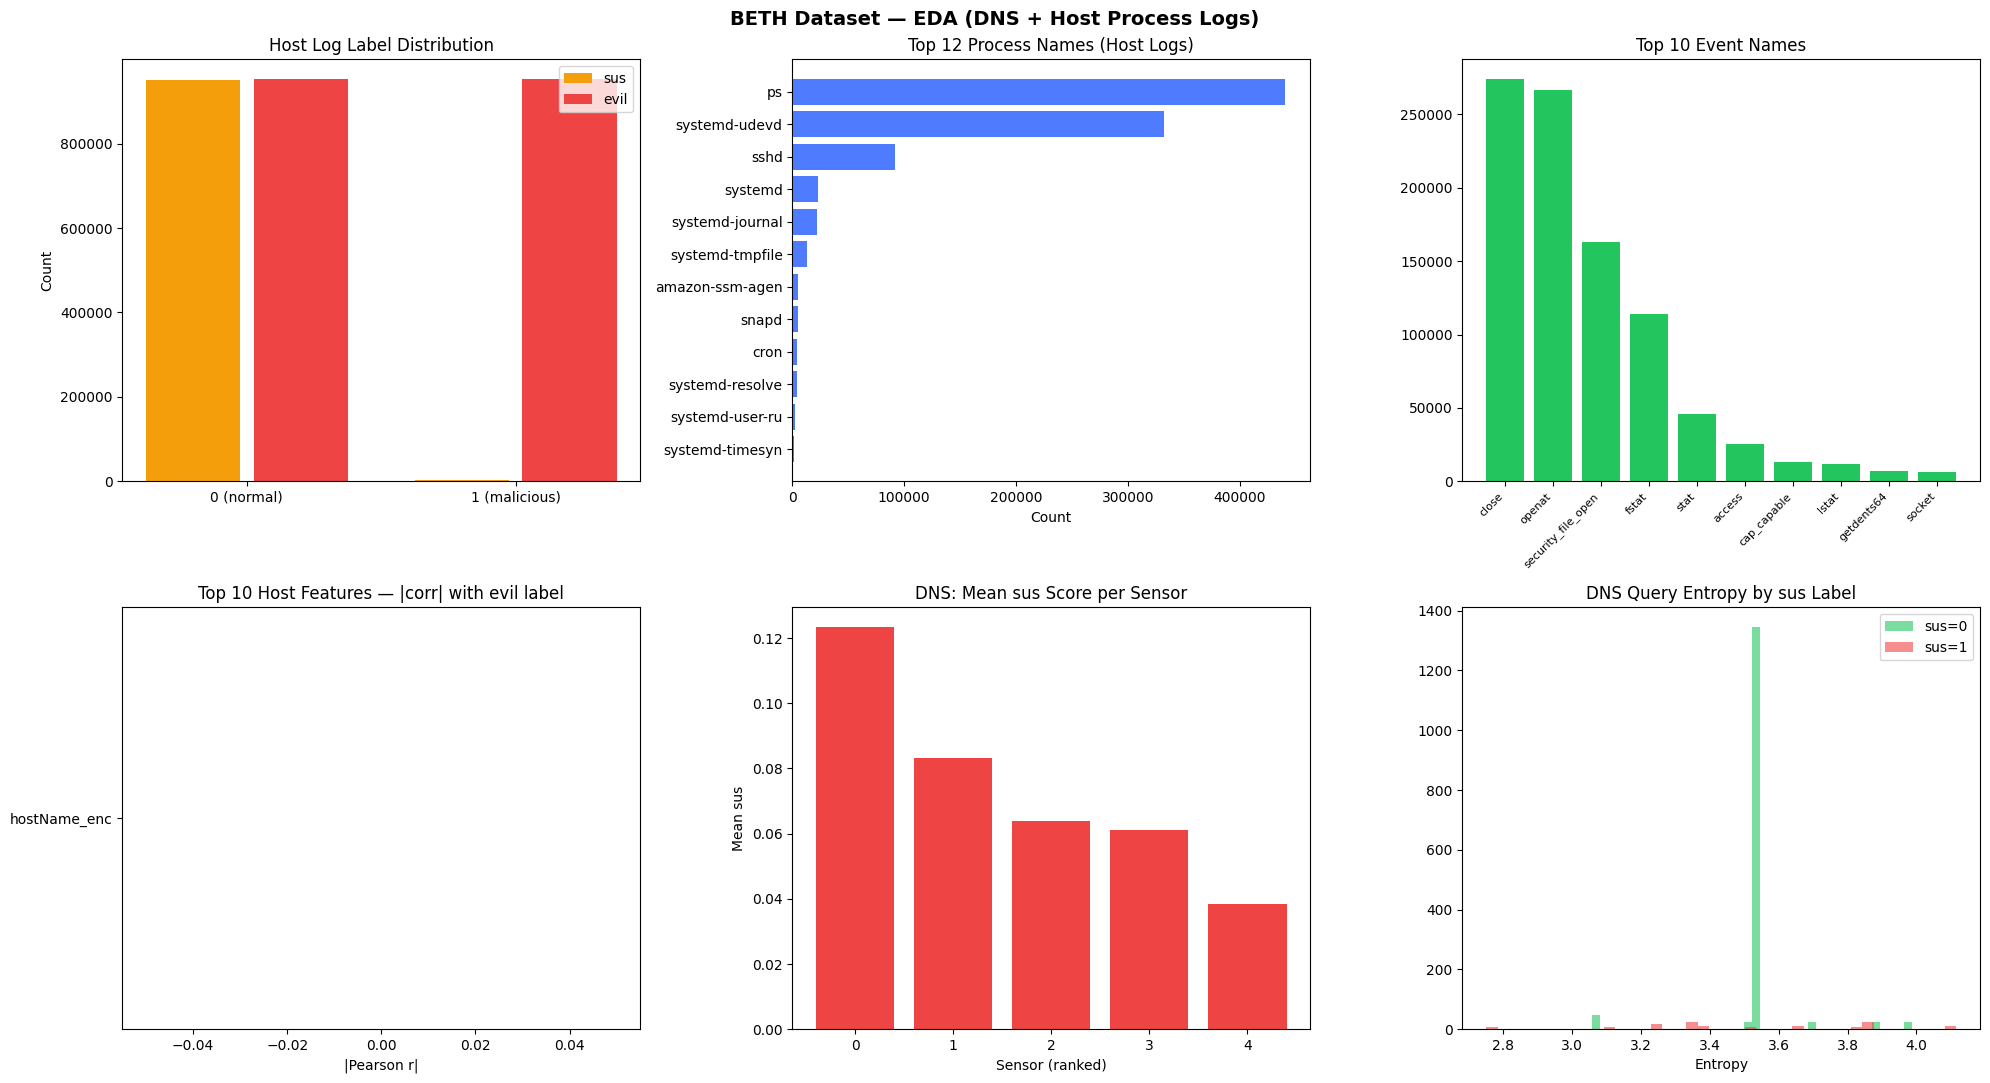

EDA saved.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('BETH Dataset — EDA (DNS + Host Process Logs)',
             fontsize=14, fontweight='bold')

# Host: sus vs evil distribution
sus_counts  = df_host['sus'].value_counts().sort_index()
evil_counts = df_host['evil'].value_counts().sort_index()
x = np.arange(2)
axes[0,0].bar(x - 0.2, sus_counts.values,  0.35, label='sus',  color=PAL[2])
axes[0,0].bar(x + 0.2, evil_counts.values, 0.35, label='evil', color=PAL[3])
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(['0 (normal)', '1 (malicious)'])
axes[0,0].set_title('Host Log Label Distribution')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Host: top process names
if 'processName' in df_host.columns:
    proc_vc = df_host['processName'].value_counts().head(12)
    axes[0,1].barh(proc_vc.index[::-1], proc_vc.values[::-1], color=PAL[0])
    axes[0,1].set_title('Top 12 Process Names (Host Logs)')
    axes[0,1].set_xlabel('Count')

# Host: eventName distribution
if 'eventName' in df_host.columns:
    ev_vc = df_host['eventName'].value_counts().head(10)
    axes[0,2].bar(range(len(ev_vc)), ev_vc.values, color=PAL[1])
    axes[0,2].set_xticks(range(len(ev_vc)))
    axes[0,2].set_xticklabels(ev_vc.index, rotation=45, ha='right', fontsize=8)
    axes[0,2].set_title('Top 10 Event Names')

# Host: feature correlation with evil label
corr = df_host[HOST_FEATS].corrwith(df_host['evil']).abs().sort_values(ascending=False)
top10 = corr.head(10)
axes[1,0].barh(top10.index[::-1], top10.values[::-1], color=PAL[4])
axes[1,0].set_title('Top 10 Host Features — |corr| with evil label')
axes[1,0].set_xlabel('|Pearson r|')

# DNS: sus distribution per sensor
if not df_dns.empty and 'SensorId' in df_dns.columns:
    sensor_sus = df_dns.groupby('SensorId')['sus'].mean().sort_values(ascending=False)
    axes[1,1].bar(range(len(sensor_sus)), sensor_sus.values, color=PAL[3])
    axes[1,1].set_title('DNS: Mean sus Score per Sensor')
    axes[1,1].set_xlabel('Sensor (ranked)')
    axes[1,1].set_ylabel('Mean sus')
elif not df_dns.empty:
    axes[1,1].bar(['DNS sus=0','DNS sus=1'],
                   df_dns['sus'].value_counts().sort_index().values,
                   color=[PAL[1],PAL[3]])
    axes[1,1].set_title('DNS: sus Label Distribution')

# DNS: query entropy vs sus (if available)
if not df_dns.empty and 'dns_query_entropy' in df_dns.columns:
    for lbl, col in zip([0,1],[PAL[1],PAL[3]]):
        m = df_dns['sus']==lbl
        axes[1,2].hist(df_dns.loc[m,'dns_query_entropy'], bins=40,
                       alpha=0.6, label=f'sus={lbl}', color=col)
    axes[1,2].set_title('DNS Query Entropy by sus Label')
    axes[1,2].set_xlabel('Entropy')
    axes[1,2].legend()
else:
    axes[1,2].set_visible(False)

plt.tight_layout()
plt.savefig('models/eda_beth.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA saved.')

In [6]:
# ── Host log feature matrix
X_host = df_host[HOST_FEATS].values
y_sus  = df_host['sus'].values.astype(int)
y_evil = df_host['evil'].values.astype(int)

X_test_host = df_test_h[HOST_FEATS].values
y_test_sus  = df_test_h['sus'].values.astype(int)
y_test_evil = df_test_h['evil'].values.astype(int)

scaler_host = RobustScaler()
X_host_sc      = scaler_host.fit_transform(X_host)
X_test_host_sc = scaler_host.transform(X_test_host)

joblib.dump(scaler_host, 'models/v2_host_scaler.pkl')
print(f'Host train: {X_host_sc.shape}  test: {X_test_host_sc.shape}')
print(f'Evil label balance: {dict(zip(*np.unique(y_evil, return_counts=True)))}')

# ── DNS feature matrix (if available)
if not df_dns.empty and len(DNS_FEATS) > 0:
    X_dns    = df_dns[DNS_FEATS].values
    y_dns_sus= df_dns['sus'].values.astype(int)
    y_dns_evil=df_dns['evil'].values.astype(int)
    scaler_dns = RobustScaler()
    X_dns_sc   = scaler_dns.fit_transform(X_dns)
    joblib.dump(scaler_dns,'models/v2_dns_scaler.pkl')
    print(f'DNS data: {X_dns_sc.shape}')
    HAS_DNS = True
else:
    HAS_DNS = False
    print('No DNS data loaded — skipping DNS-specific models')

Host train: (952111, 15)  test: (763144, 15)
Evil label balance: {np.int64(0): np.int64(952111)}
DNS data: (1614, 9)



Training HMM [normal] on 950,056 samples...


  HMM [normal] | states=5 | log-L/step: -8.604

Training HMM [sus] on 2,055 samples...


  HMM [sus] | states=5 | log-L/step: -15.232

Training HMM [evil] on 0 samples...
  Skipping — not enough samples (0)

HMM quick validation: 19/20 (95%)


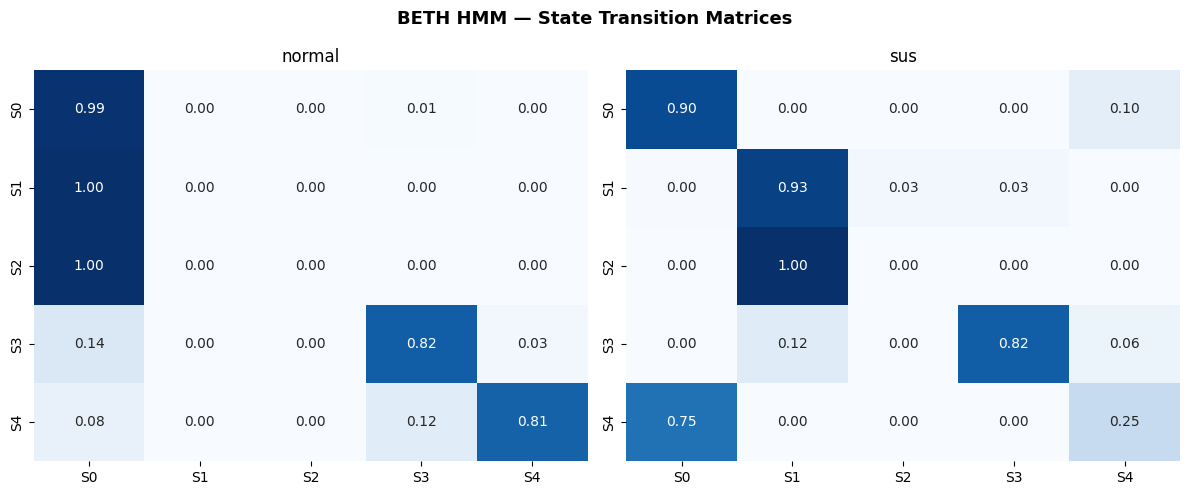

HMM models saved.


In [7]:
# ════════════════════════════════════════════════════════
# BETH has timestamped process events — perfect for HMM.
# We model: normal, sus (suspicious), evil (confirmed attack)
# Each HMM learns the state transition pattern for its class.
# ════════════════════════════════════════════════════════
T_SEQ   = 20   # sequence window
N_COMPS = 5    # hidden states

CLASSES_HMM = {
    'normal': (y_sus == 0) & (y_evil == 0),
    'sus'   : (y_sus == 1) & (y_evil == 0),
    'evil'  : y_evil == 1,
}

def build_sequences_beth(X, mask, n_seq=200, T=T_SEQ):
    X_cls = X[mask]
    seqs, lengths = [], []
    if len(X_cls) < T:
        print(f'  Not enough samples: {len(X_cls)}')
        return None, None
    for _ in range(min(n_seq, len(X_cls)//T)):
        start = np.random.randint(0, len(X_cls)-T)
        seqs.append(X_cls[start:start+T]
                    + np.random.randn(T, X_cls.shape[1])*0.01)
        lengths.append(T)
    return np.vstack(seqs), lengths

hmm_models = {}
for cls, mask in CLASSES_HMM.items():
    n = mask.sum()
    print(f'\nTraining HMM [{cls}] on {n:,} samples...')
    if n < T_SEQ * 5:
        print(f'  Skipping — not enough samples ({n})')
        continue
    X_hmm, lengths = build_sequences_beth(X_host_sc, mask)
    if X_hmm is None:
        continue
    model_hmm = hmm.GaussianHMM(
        n_components=N_COMPS,
        covariance_type='diag',
        n_iter=100,
        random_state=RANDOM,
        tol=1e-4
    )
    try:
        model_hmm.fit(X_hmm, lengths)
        ll = model_hmm.score(X_hmm[:T_SEQ]) / T_SEQ
        hmm_models[cls] = model_hmm
        print(f'  HMM [{cls}] | states={N_COMPS} | log-L/step: {ll:.3f}')
    except Exception as e:
        print(f'  HMM [{cls}] failed: {e}')

def hmm_classify(seq_2d):
    scores = {}
    for cls, m in hmm_models.items():
        try:    scores[cls] = m.score(seq_2d) / len(seq_2d)
        except: scores[cls] = -1e9
    return max(scores, key=scores.get), scores

# Quick validation
correct = 0; total = 0
for cls, mask in CLASSES_HMM.items():
    if cls not in hmm_models: continue
    X_cls = X_host_sc[mask]
    for _ in range(10):
        if len(X_cls) < T_SEQ: continue
        start = np.random.randint(0, len(X_cls)-T_SEQ)
        pred, _ = hmm_classify(X_cls[start:start+T_SEQ])
        if pred == cls: correct += 1
        total += 1
print(f'\nHMM quick validation: {correct}/{total} ({correct/max(total,1)*100:.0f}%)')

joblib.dump(hmm_models, 'models/v2_hmm_models.pkl')

# Transition matrix plots
if hmm_models:
    n_plots = len(hmm_models)
    fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))
    if n_plots == 1: axes = [axes]
    fig.suptitle('BETH HMM — State Transition Matrices', fontsize=13, fontweight='bold')
    for ax, (cls, m) in zip(axes, hmm_models.items()):
        sns.heatmap(m.transmat_, ax=ax, annot=True, fmt='.2f', cmap='Blues',
                    cbar=False,
                    xticklabels=[f'S{i}' for i in range(N_COMPS)],
                    yticklabels=[f'S{i}' for i in range(N_COMPS)])
        ax.set_title(cls)
    plt.tight_layout()
    plt.savefig('models/hmm_transitions.png', dpi=120)
    plt.show()
print('HMM models saved.')

Optimal K (max silhouette): 2


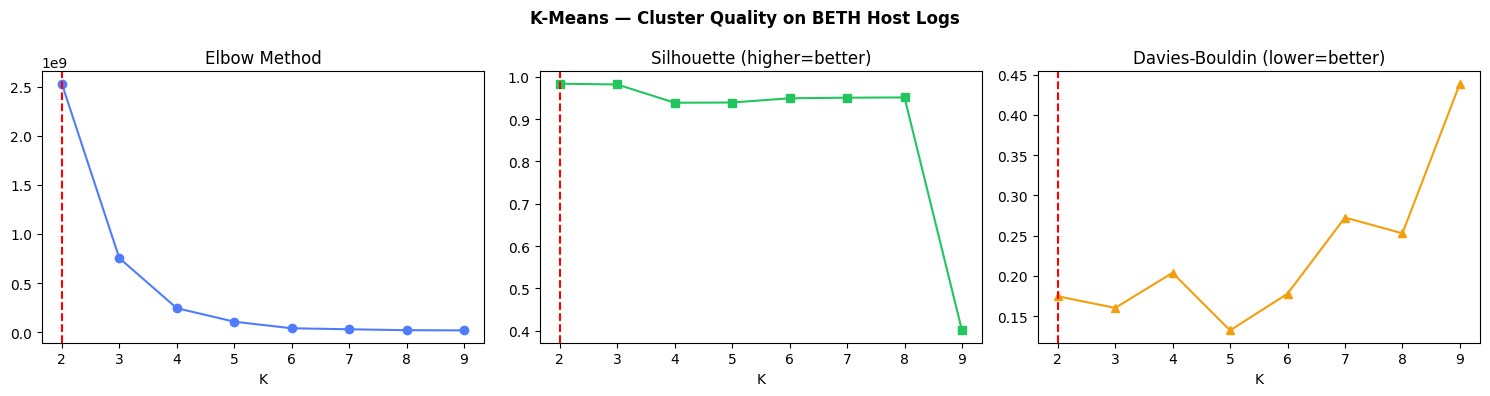

K-Means (k=2) | Silhouette: 0.9839
  Cluster 0: 950,154 samples | evil_rate=0.000 | sus_rate=0.002
  Cluster 1:  1,957 samples | evil_rate=0.000 | sus_rate=0.004
K-Means saved.


In [8]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

K_range  = range(2, 10)
inertias, sils, dbs = [], [], []

for k in K_range:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM)
    lbl = km.fit_predict(X_host_sc)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_host_sc, lbl,
                                  sample_size=min(5000, len(X_host_sc)),
                                  random_state=RANDOM))
    dbs.append(davies_bouldin_score(X_host_sc, lbl))

optimal_k = list(K_range)[int(np.argmax(sils))]
print(f'Optimal K (max silhouette): {optimal_k}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('K-Means — Cluster Quality on BETH Host Logs', fontsize=12, fontweight='bold')
axes[0].plot(K_range, inertias, 'o-', color=PAL[0])
axes[0].axvline(optimal_k, color='red', linestyle='--')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('K')
axes[1].plot(K_range, sils, 's-', color=PAL[1])
axes[1].axvline(optimal_k, color='red', linestyle='--')
axes[1].set_title('Silhouette (higher=better)'); axes[1].set_xlabel('K')
axes[2].plot(K_range, dbs, '^-', color=PAL[2])
axes[2].axvline(optimal_k, color='red', linestyle='--')
axes[2].set_title('Davies-Bouldin (lower=better)'); axes[2].set_xlabel('K')
plt.tight_layout()
plt.savefig('models/kmeans_metrics.png', dpi=120)
plt.show()

km_final  = KMeans(n_clusters=optimal_k, init='k-means++',
                    n_init=20, random_state=RANDOM)
km_labels = km_final.fit_predict(X_host_sc)
sil_final = silhouette_score(X_host_sc, km_labels,
                              sample_size=min(5000, len(X_host_sc)),
                              random_state=RANDOM)
print(f'K-Means (k={optimal_k}) | Silhouette: {sil_final:.4f}')

# Check how well clusters align with evil label
for k in range(optimal_k):
    mask = km_labels == k
    evil_rate = y_evil[mask].mean()
    sus_rate  = y_sus[mask].mean()
    print(f'  Cluster {k}: {mask.sum():6,} samples | evil_rate={evil_rate:.3f} | sus_rate={sus_rate:.3f}')

joblib.dump(km_final, 'models/v2_kmeans.pkl')
print('K-Means saved.')

Running HDBSCAN on 50,000 samples...
HDBSCAN | Clusters: 106 | Noise points: 1954 (3.9%)
        | Silhouette: 0.3085
  Cluster  0:   103 | evil_rate=0.000 | sus_rate=1.000
  Cluster  1:    97 | evil_rate=0.000 | sus_rate=0.000
  Cluster  2:    94 | evil_rate=0.000 | sus_rate=0.000
  Cluster  3:    85 | evil_rate=0.000 | sus_rate=0.000
  Cluster  4:   257 | evil_rate=0.000 | sus_rate=0.004
  Cluster  5:   102 | evil_rate=0.000 | sus_rate=0.000
  Cluster  6:    95 | evil_rate=0.000 | sus_rate=0.000
  Cluster  7:    64 | evil_rate=0.000 | sus_rate=0.000
  Cluster  8:    72 | evil_rate=0.000 | sus_rate=0.000
  Cluster  9:   101 | evil_rate=0.000 | sus_rate=0.010
  Cluster 10:    72 | evil_rate=0.000 | sus_rate=0.000
  Cluster 11:   112 | evil_rate=0.000 | sus_rate=0.000
  Cluster 12:   138 | evil_rate=0.000 | sus_rate=0.007
  Cluster 13:   163 | evil_rate=0.000 | sus_rate=0.000
  Cluster 14:    65 | evil_rate=0.000 | sus_rate=0.000
  Cluster 15:   118 | evil_rate=0.000 | sus_rate=0.000
  

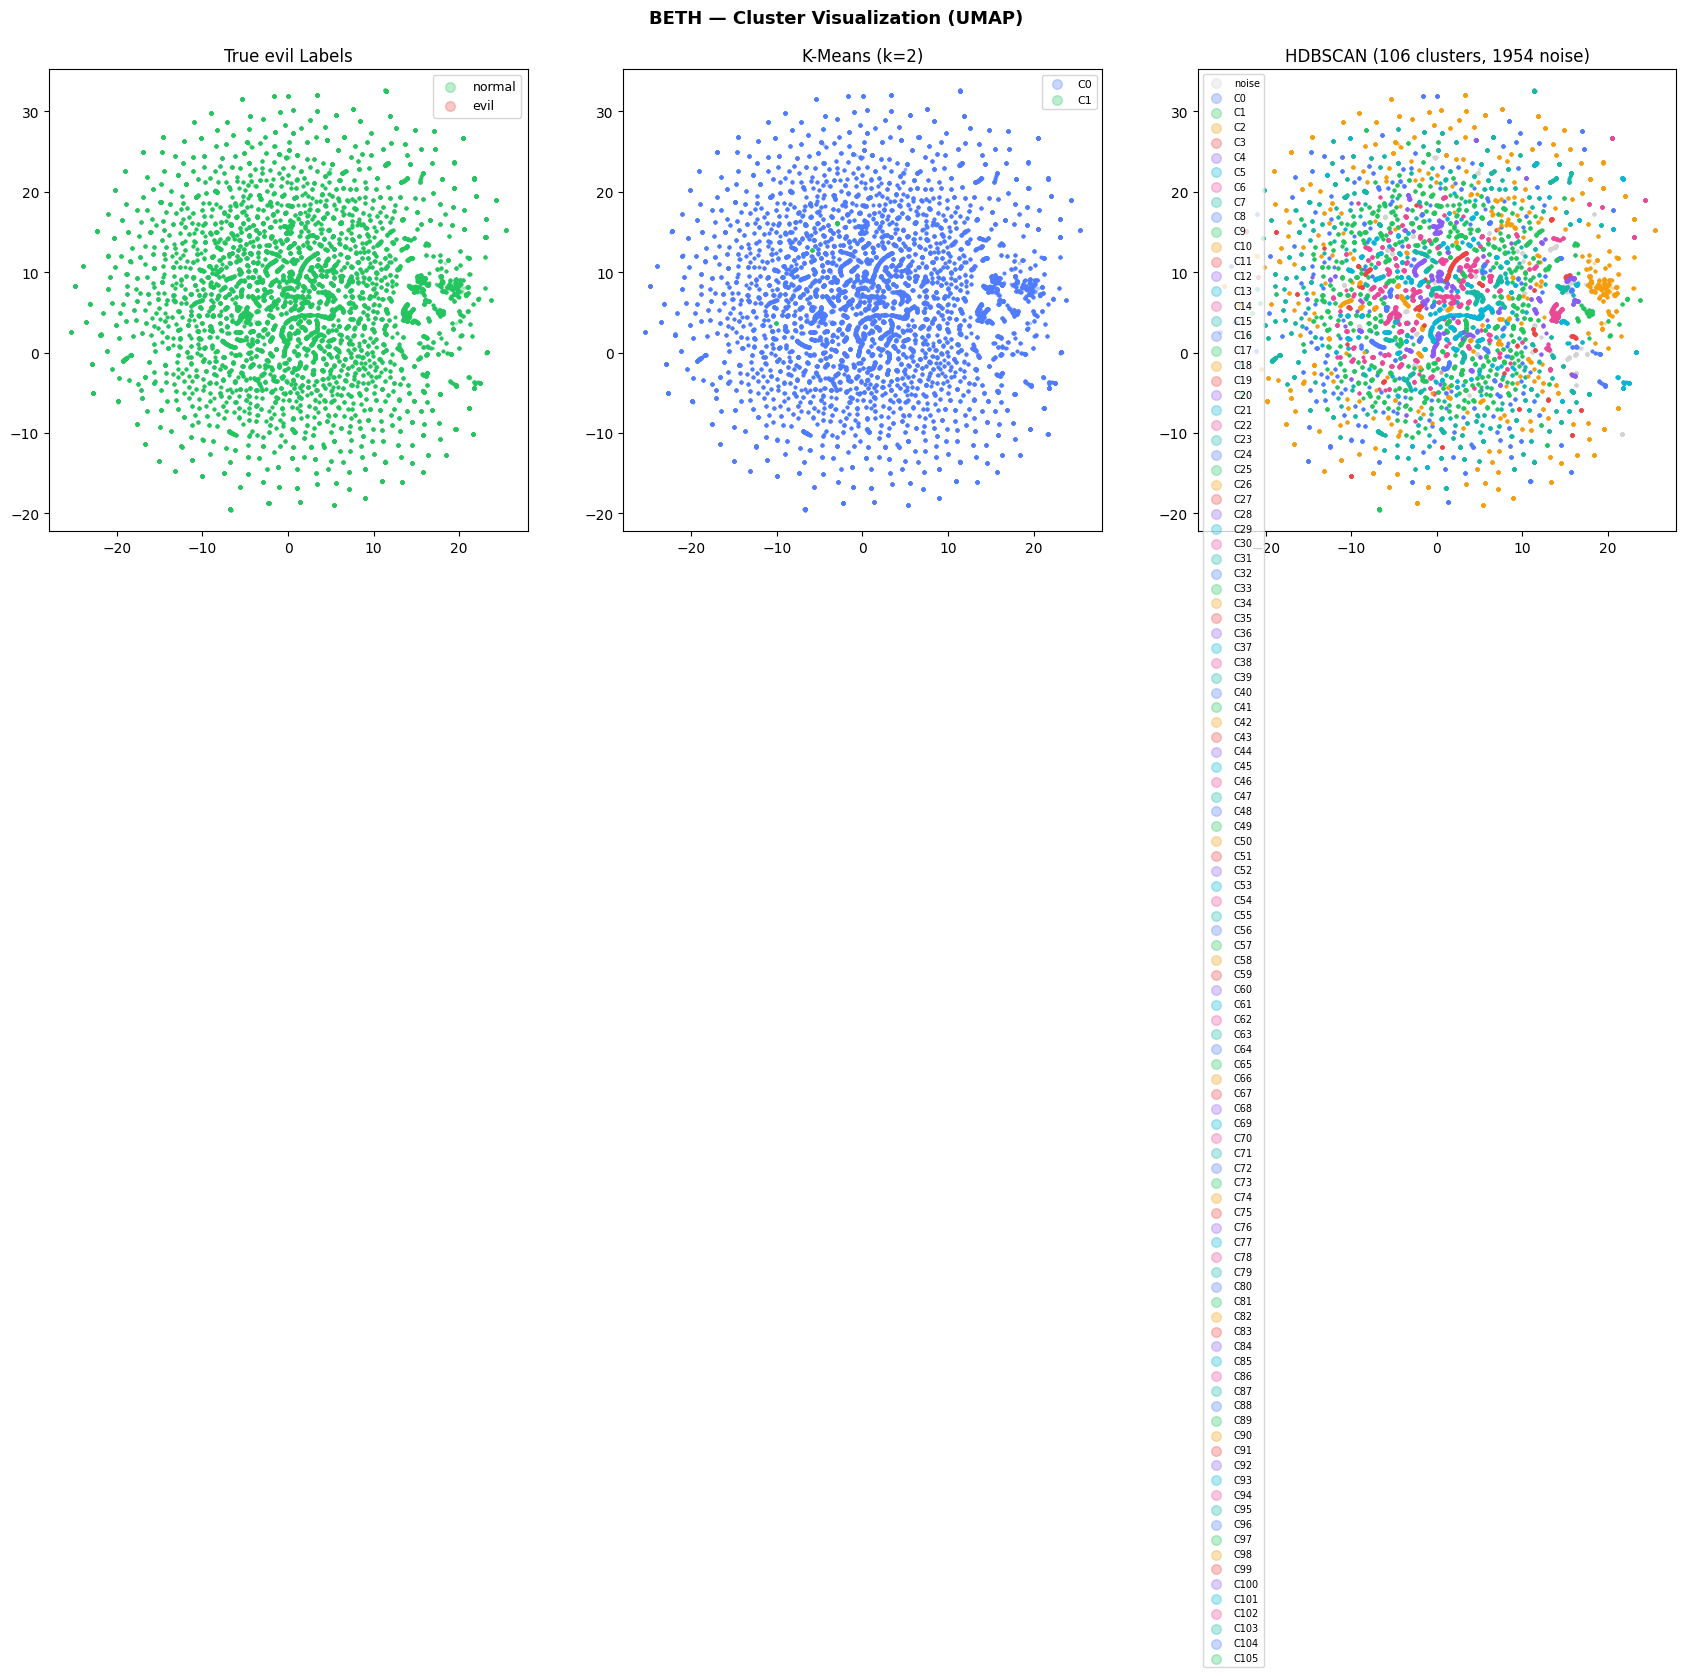

HDBSCAN + visualization saved.


In [9]:
# Subsample for HDBSCAN speed (it's O(n log n) but still slow on large data)
N_HDBSCAN = min(50000, len(X_host_sc))
idx_sub   = np.random.choice(len(X_host_sc), N_HDBSCAN, replace=False)
X_sub     = X_host_sc[idx_sub]
y_sub_evil= y_evil[idx_sub]
y_sub_sus = y_sus[idx_sub]

print(f'Running HDBSCAN on {N_HDBSCAN:,} samples...')
hdb = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    cluster_selection_epsilon=0.5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)
hdb_labels = hdb.fit_predict(X_sub)
n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise    = (hdb_labels == -1).sum()
print(f'HDBSCAN | Clusters: {n_clusters} | Noise points: {n_noise} ({n_noise/N_HDBSCAN*100:.1f}%)')
if n_clusters > 1:
    mask_valid = hdb_labels != -1
    sil = silhouette_score(X_sub[mask_valid], hdb_labels[mask_valid],
                            sample_size=min(3000, mask_valid.sum()))
    print(f'        | Silhouette: {sil:.4f}')

for c in sorted(set(hdb_labels)):
    if c == -1: continue
    m = hdb_labels == c
    print(f'  Cluster {c:2d}: {m.sum():5,} | evil_rate={y_sub_evil[m].mean():.3f} | sus_rate={y_sub_sus[m].mean():.3f}')

joblib.dump(hdb, 'models/v2_hdbscan.pkl')

# 2D projection
print('\nBuilding 2D projection...')
if HAS_UMAP:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=RANDOM,
                         n_neighbors=30, min_dist=0.1)
    proj    = reducer.fit_transform(X_sub)
    joblib.dump(reducer, 'models/v2_umap.pkl')
    proj_method = 'UMAP'
else:
    proj = PCA(n_components=2, random_state=RANDOM).fit_transform(X_sub)
    proj_method = 'PCA'

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(f'BETH — Cluster Visualization ({proj_method})', fontsize=13, fontweight='bold')

# True evil label
for lbl, col, name in zip([0,1],[PAL[1],PAL[3]],['normal','evil']):
    m = y_sub_evil == lbl
    axes[0].scatter(proj[m,0], proj[m,1], s=3, alpha=0.3, color=col, label=name)
axes[0].set_title('True evil Labels')
axes[0].legend(markerscale=4, fontsize=9)

# K-Means (refit on subsample)
km_sub = KMeans(n_clusters=optimal_k, init='k-means++',
                n_init=10, random_state=RANDOM)
km_sub_labels = km_sub.fit_predict(X_sub)
for k in range(optimal_k):
    m = km_sub_labels == k
    axes[1].scatter(proj[m,0], proj[m,1], s=3, alpha=0.3,
                    color=PAL[k % len(PAL)], label=f'C{k}')
axes[1].set_title(f'K-Means (k={optimal_k})')
axes[1].legend(markerscale=4, fontsize=8)

# HDBSCAN
for lbl in sorted(set(hdb_labels)):
    m   = hdb_labels == lbl
    col = 'lightgray' if lbl == -1 else PAL[lbl % len(PAL)]
    nm  = 'noise' if lbl == -1 else f'C{lbl}'
    axes[2].scatter(proj[m,0], proj[m,1], s=3, alpha=0.3, color=col, label=nm)
axes[2].set_title(f'HDBSCAN ({n_clusters} clusters, {n_noise} noise)')
axes[2].legend(markerscale=4, fontsize=7)

plt.tight_layout()
plt.savefig('models/cluster_viz_beth.png', dpi=130, bbox_inches='tight')
plt.show()
print('HDBSCAN + visualization saved.')

Process sessions built: 549
Sample session: ['close', 'fstat', 'openat', 'security_file_open', 'close', 'fstat', 'openat', 'close']...

Process2Vec | vocab: 34 | dim: 64
Process2Vec saved.


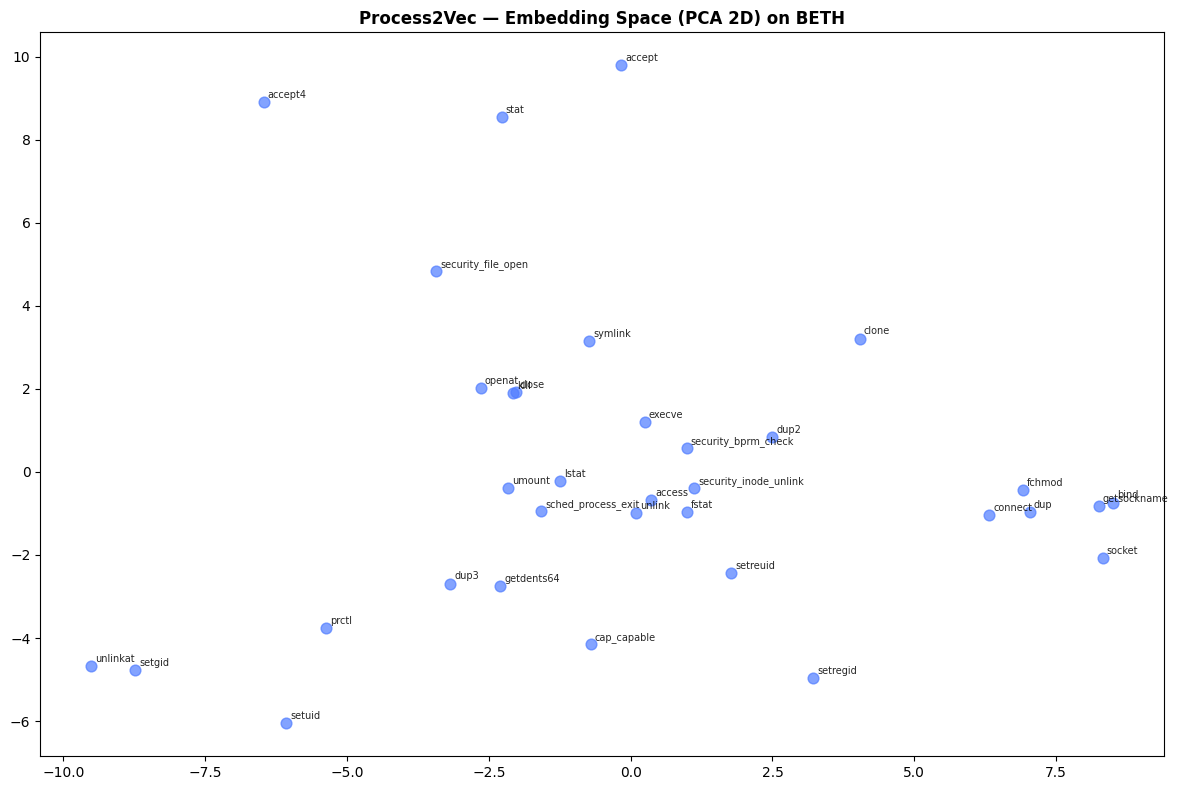

In [10]:
# ════════════════════════════════════════════════════════
# BETH host logs = sequences of syscall events per process.
# Treat each processName as a "word" and each process
# session (grouped by processId) as a "sentence".
# Word2Vec learns that similar processes cluster together.
# ════════════════════════════════════════════════════════

if 'processName' in df_host.columns and 'processId' in df_host.columns:
    # Build sentences: group by processId → list of eventNames
    event_col = 'eventName' if 'eventName' in df_host.columns else 'processName'
    sessions  = (df_host
                 .sort_values('processId')
                 .groupby('processId')[event_col]
                 .apply(lambda x: x.astype(str).tolist())
                 .tolist())
    # Filter out very short sessions
    sessions = [s for s in sessions if len(s) >= 3]
    print(f'Process sessions built: {len(sessions):,}')
    print(f'Sample session: {sessions[0][:8]}...')

    # Augment — shuffle within sessions
    aug_sessions = []
    for s in sessions * 3:
        shuf = s.copy()
        np.random.shuffle(shuf)
        aug_sessions.append(shuf)
    aug_sessions.extend(sessions)

    proc2vec = Word2Vec(
        sentences=aug_sessions,
        vector_size=64,
        window=5,
        min_count=2,
        epochs=50,
        workers=4,
        seed=RANDOM
    )
    vocab_size = len(proc2vec.wv.key_to_index)
    print(f'\nProcess2Vec | vocab: {vocab_size} | dim: {proc2vec.wv.vector_size}')

    # Show most similar processes
    key_procs = ['bash','sh','python3','curl','wget','sshd','cron','systemd']
    for proc in key_procs:
        if proc in proc2vec.wv:
            sim = proc2vec.wv.most_similar(proc, topn=3)
            print(f'  {proc:12s} -> {[(s, round(sc,2)) for s,sc in sim]}')

    proc2vec.save('models/v2_process2vec.model')
    print('Process2Vec saved.')

    # Visualize embedding space
    vocab = list(proc2vec.wv.key_to_index.keys())[:50]
    vecs  = np.array([proc2vec.wv[w] for w in vocab])
    pca2  = PCA(n_components=2, random_state=RANDOM).fit_transform(vecs)

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.scatter(pca2[:,0], pca2[:,1], s=60, color=PAL[0], alpha=0.7)
    for i, word in enumerate(vocab):
        ax.annotate(word, (pca2[i,0], pca2[i,1]),
                    fontsize=7, alpha=0.85,
                    xytext=(3, 3), textcoords='offset points')
    ax.set_title('Process2Vec — Embedding Space (PCA 2D) on BETH', fontweight='bold')
    plt.tight_layout()
    plt.savefig('models/process2vec_embed.png', dpi=120)
    plt.show()
else:
    print('processName/processId columns not found — skipping Process2Vec')
    proc2vec = None

PCA2Vec | 15 features -> 3 components (95% var)


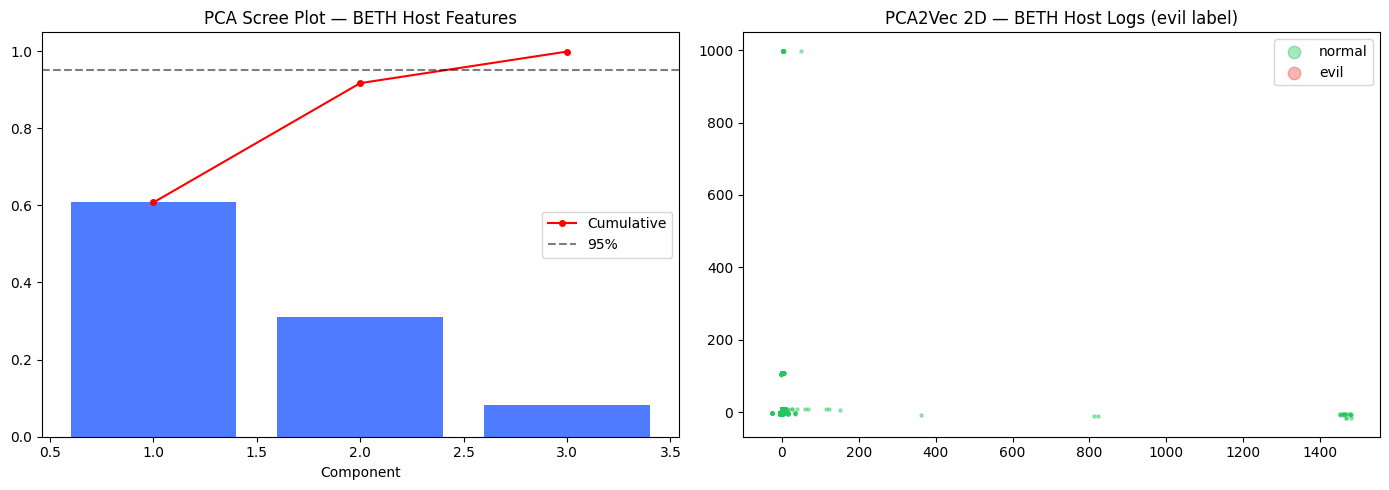

Computing HMM2Vec embeddings...
HMM2Vec shape: (300, 2)  dims=['normal', 'sus']
PCA2Vec + HMM2Vec saved.


In [11]:
# ── PCA2Vec: compress host features to 95% variance
pca_full = PCA(n_components=0.95, random_state=RANDOM)
X_pca    = pca_full.fit_transform(X_host_sc)
vr       = pca_full.explained_variance_ratio_
print(f'PCA2Vec | {len(HOST_FEATS)} features -> {X_pca.shape[1]} components (95% var)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(vr)+1), vr, color=PAL[0])
axes[0].plot(range(1, len(vr)+1), np.cumsum(vr), 'r-o', ms=4, label='Cumulative')
axes[0].axhline(0.95, color='black', linestyle='--', alpha=0.5, label='95%')
axes[0].set_title('PCA Scree Plot — BETH Host Features')
axes[0].set_xlabel('Component')
axes[0].legend()

pca2d = PCA(n_components=2, random_state=RANDOM).fit_transform(X_host_sc)
N_PLOT = min(10000, len(pca2d))
idx_p  = np.random.choice(len(pca2d), N_PLOT, replace=False)
for lbl, col, name in zip([0,1],[PAL[1],PAL[3]],['normal','evil']):
    m = y_evil[idx_p] == lbl
    axes[1].scatter(pca2d[idx_p][m,0], pca2d[idx_p][m,1],
                    s=5, alpha=0.4, label=name, color=col)
axes[1].set_title('PCA2Vec 2D — BETH Host Logs (evil label)')
axes[1].legend(markerscale=4)
plt.tight_layout()
plt.savefig('models/pca2vec_beth.png', dpi=120)
plt.show()
joblib.dump(pca_full, 'models/v2_pca2vec.pkl')

# ── HMM2Vec: encode each sample as vector of log-likelihoods
hmm_mods = joblib.load('models/v2_hmm_models.pkl')

def hmm2vec(X_flat, hmm_mods, T=20, max_n=300):
    vecs = []
    for i in range(0, min(len(X_flat), max_n * T), T):
        chunk = X_flat[i:i+T]
        if len(chunk) < T:
            chunk = np.vstack([chunk,
                                np.zeros((T-len(chunk), X_flat.shape[1]))])
        sc = []
        for cls, m in hmm_mods.items():
            try:    sc.append(m.score(chunk) / T)
            except: sc.append(-999.0)
        vecs.append(sc)
    return np.array(vecs)

if hmm_mods:
    print('Computing HMM2Vec embeddings...')
    H2V = hmm2vec(X_host_sc[:300*20], hmm_mods)
    print(f'HMM2Vec shape: {H2V.shape}  dims={list(hmm_mods.keys())}')
    np.save('models/v2_hmm2vec_sample.npy', H2V)
    print('PCA2Vec + HMM2Vec saved.')
else:
    print('No HMM models available for HMM2Vec.')

DNS data shape: (1614, 9)
DNS evil: 24 / 1,614

DNS K-Means cluster → evil rate:
  Cluster 0: 1,356 | evil_rate=0.000
  Cluster 1: 138 | evil_rate=0.174
  Cluster 2: 96 | evil_rate=0.000
  Cluster 3: 24 | evil_rate=0.000

DNS HDBSCAN | Clusters: 7 | Noise: 72


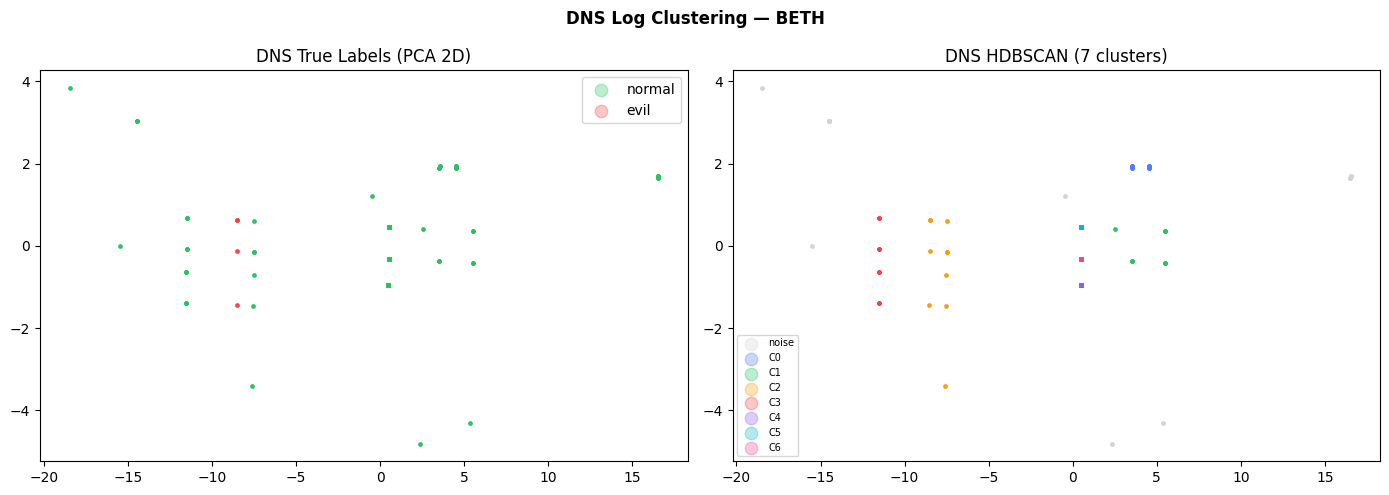

DNS models saved.


In [12]:
if HAS_DNS:
    print(f'DNS data shape: {X_dns_sc.shape}')
    print(f'DNS evil: {y_dns_evil.sum():,} / {len(y_dns_evil):,}')

    # DNS K-Means
    km_dns = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=RANDOM)
    km_dns_labels = km_dns.fit_predict(X_dns_sc)
    print('\nDNS K-Means cluster → evil rate:')
    for k in range(4):
        m = km_dns_labels == k
        print(f'  Cluster {k}: {m.sum():,} | evil_rate={y_dns_evil[m].mean():.3f}')
    joblib.dump(km_dns, 'models/v2_dns_kmeans.pkl')

    # DNS HDBSCAN
    N_DNS_SUB = min(20000, len(X_dns_sc))
    idx_dns   = np.random.choice(len(X_dns_sc), N_DNS_SUB, replace=False)
    hdb_dns   = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=5,
                                  prediction_data=True)
    hdb_dns_labels = hdb_dns.fit_predict(X_dns_sc[idx_dns])
    n_dns_clusters = len(set(hdb_dns_labels)) - (1 if -1 in hdb_dns_labels else 0)
    print(f'\nDNS HDBSCAN | Clusters: {n_dns_clusters} | '
          f'Noise: {(hdb_dns_labels==-1).sum()}')
    joblib.dump(hdb_dns, 'models/v2_dns_hdbscan.pkl')

    # DNS 2D viz
    proj_dns = PCA(n_components=2, random_state=RANDOM).fit_transform(X_dns_sc[idx_dns])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('DNS Log Clustering — BETH', fontsize=12, fontweight='bold')
    for lbl, col, name in zip([0,1],[PAL[1],PAL[3]],['normal','evil']):
        m = y_dns_evil[idx_dns] == lbl
        axes[0].scatter(proj_dns[m,0], proj_dns[m,1],
                        s=5, alpha=0.3, color=col, label=name)
    axes[0].set_title('DNS True Labels (PCA 2D)')
    axes[0].legend(markerscale=4)
    for c in sorted(set(hdb_dns_labels)):
        m   = hdb_dns_labels == c
        col = 'lightgray' if c == -1 else PAL[c % len(PAL)]
        axes[1].scatter(proj_dns[m,0], proj_dns[m,1],
                        s=5, alpha=0.3, color=col,
                        label='noise' if c==-1 else f'C{c}')
    axes[1].set_title(f'DNS HDBSCAN ({n_dns_clusters} clusters)')
    axes[1].legend(markerscale=4, fontsize=7)
    plt.tight_layout()
    plt.savefig('models/dns_cluster_viz.png', dpi=120)
    plt.show()
    print('DNS models saved.')
else:
    print('No DNS data — DNS-specific models skipped.')

In [13]:
print('\n' + '='*60)
print('  NOTEBOOK 3 — BETH DATASET — ARTIFACTS SUMMARY')
print('='*60)

manifest = {
    'version'      : '2.0',
    'dataset'      : 'BETH',
    'host_features': HOST_FEATS,
    'dns_features' : DNS_FEATS if not df_dns.empty else [],
    'hmm_classes'  : list(hmm_models.keys()),
    'kmeans_k'     : int(optimal_k),
    'n_classes_beth': 3,
    'beth_classes' : ['normal','suspicious','evil'],
    'models': {
        'host_scaler'      : 'v2_host_scaler.pkl',
        'host_imputer'     : 'v2_host_imputer.pkl',
        'hmm_models'       : 'v2_hmm_models.pkl',
        'kmeans'           : 'v2_kmeans.pkl',
        'hdbscan'          : 'v2_hdbscan.pkl',
        'process2vec'      : 'v2_process2vec.model',
        'pca2vec'          : 'v2_pca2vec.pkl',
        'hmm2vec_sample'   : 'v2_hmm2vec_sample.npy',
    }
}
if HAS_UMAP:
    manifest['models']['umap'] = 'v2_umap.pkl'
if HAS_DNS:
    manifest['models']['dns_scaler']  = 'v2_dns_scaler.pkl'
    manifest['models']['dns_kmeans']  = 'v2_dns_kmeans.pkl'
    manifest['models']['dns_hdbscan'] = 'v2_dns_hdbscan.pkl'
if HAS_TF:
    manifest['models']['transfer_source']    = 'v2_transfer_source.keras'
    manifest['models']['transfer_finetuned'] = 'v2_transfer_finetuned.keras'
    manifest['models']['feature_extractor']  = 'v2_feature_extractor.keras'

with open('models/v2_nb3_manifest.json','w') as f:
    json.dump(manifest, f, indent=2)

for k, v in manifest['models'].items():
    path = f'models/{v}'
    size = os.path.getsize(path) if os.path.exists(path) else 0
    print(f'  {v:<45} {size:>10,} bytes')

print('\nNB3 complete. ZIP models/ and download from Kaggle Output tab.')
print('Merge with NB1 + NB2 models on your i3 machine.')


  NOTEBOOK 3 — BETH DATASET — ARTIFACTS SUMMARY
  v2_host_scaler.pkl                                   735 bytes
  v2_host_imputer.pkl                                1,055 bytes
  v2_hmm_models.pkl                                  4,373 bytes
  v2_kmeans.pkl                                  3,809,427 bytes
  v2_hdbscan.pkl                                26,828,035 bytes
  v2_process2vec.model                              26,293 bytes
  v2_pca2vec.pkl                                     1,551 bytes
  v2_hmm2vec_sample.npy                              4,928 bytes
  v2_umap.pkl                                   50,077,809 bytes
  v2_dns_scaler.pkl                                    639 bytes
  v2_dns_kmeans.pkl                                  7,471 bytes
  v2_dns_hdbscan.pkl                               601,499 bytes
  v2_transfer_source.keras                               0 bytes
  v2_transfer_finetuned.keras                            0 bytes
  v2_feature_extractor.keras             